In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from tensorflow.keras.applications import EfficientNetB0

PROJECT_PATH = '/content/drive/MyDrive/Brain-Tumor-Classification'

Mounted at /content/drive


In [2]:
model_transfer = tf.keras.models.load_model(
    f'{PROJECT_PATH}/models/transfer_best_phase2.keras'
)

print("Model loaded successfully.")
print(f"Model input shape: {model_transfer.input_shape}")

Model loaded successfully.
Model input shape: (None, 224, 224, 3)


In [8]:
# Load test data
processed_path = f'{PROJECT_PATH}/data/processed'

X_test = np.load(f'{processed_path}/X_test_transfer.npy')
y_test = np.load(f'{processed_path}/y_test_transfer.npy')

X_test = (X_test * 255.0).astype('float32')

y_true = np.argmax(y_test, axis=1)
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print(f"Test data shape: {X_test.shape}")

Test data shape: (1600, 224, 224, 3)


In [14]:
# Grad-CAM using direct EfficientNet access
def make_gradcam_heatmap(img_array, model):

    efficientnet = model.get_layer('efficientnetb0')

    # Model from input to last conv output
    last_conv_model = tf.keras.Model(
        inputs=efficientnet.input,
        outputs=efficientnet.get_layer('top_conv').output
    )

    # Model from last conv output to final prediction
    classifier_input = tf.keras.Input(
        shape=efficientnet.get_layer('top_conv').output.shape[1:]
    )
    x = classifier_input
    for layer in model.layers[2:]:  # skip input + efficientnet layers
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_output = last_conv_model(img_array)
        tape.watch(conv_output)
        predictions = classifier_model(conv_output)
        pred_class = tf.argmax(predictions[0])
        class_score = predictions[:, pred_class]

    gradients = tape.gradient(class_score, conv_output)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    heatmap = conv_output[0] @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), pred_class.numpy()

In [4]:
# Define visualization function
def display_gradcam(img_array, heatmap, true_label, pred_label,
                    class_names, alpha=0.4):
    """
    Overlay Grad-CAM heatmap on original image.

    Args:
        img_array: original image (224, 224, 3), values 0-255
        heatmap: 2D array from make_gradcam_heatmap
        true_label: integer true class
        pred_label: integer predicted class
        class_names: list of class name strings
        alpha: heatmap transparency (0=invisible, 1=opaque)
    """
    # Resize heatmap to match image size
    heatmap_resized = cv2.resize(heatmap, (224, 224))

    # Convert heatmap to RGB colormap (jet: blue=low, red=high)
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    heatmap_colored = (heatmap_colored * 255).astype('uint8')

    # Overlay on original image
    img_display = img_array.astype('uint8')
    superimposed = cv2.addWeighted(img_display, 1 - alpha,
                                    heatmap_colored, alpha, 0)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_display)
    axes[0].set_title('Original MRI', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    correct = true_label == pred_label
    color = 'green' if correct else 'red'
    axes[2].set_title(
        f'True: {class_names[true_label]}\n'
        f'Predicted: {class_names[pred_label]}',
        fontsize=12, color=color
    )
    axes[2].axis('off')

    plt.tight_layout()
    return fig

In [11]:
# Find last conv layer name
for layer in reversed(model_transfer.layers):
    print(layer.name, '-', layer.__class__.__name__)
    break

# More detailed search inside EfficientNet
efficientnet_layer = model_transfer.get_layer('efficientnetb0')
for layer in reversed(efficientnet_layer.layers):
    if 'conv' in layer.name.lower():
        print(f"Last conv layer: {layer.name}")
        break

dense_1 - Dense
Last conv layer: top_conv


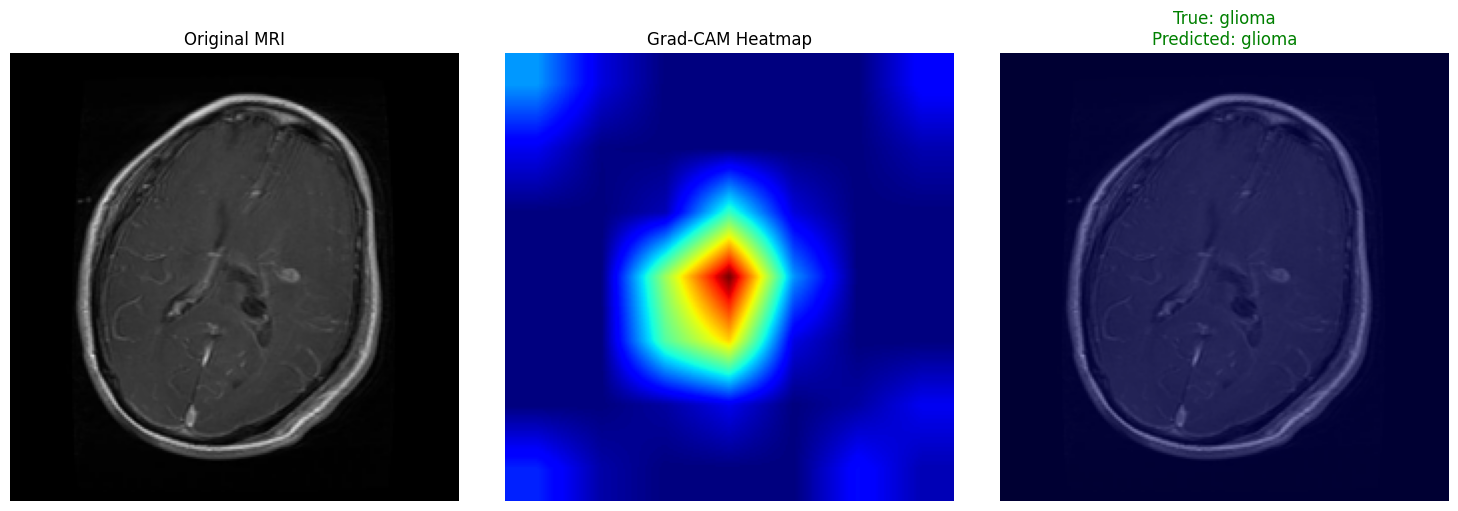

Saved: gradcam_glioma.png


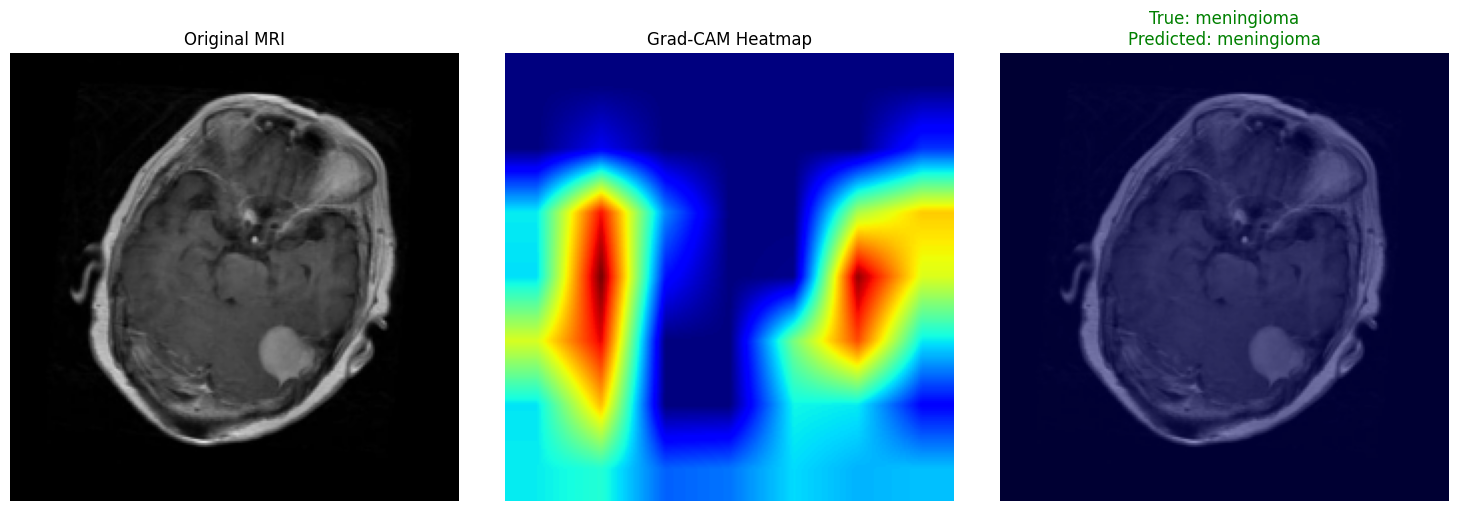

Saved: gradcam_meningioma.png


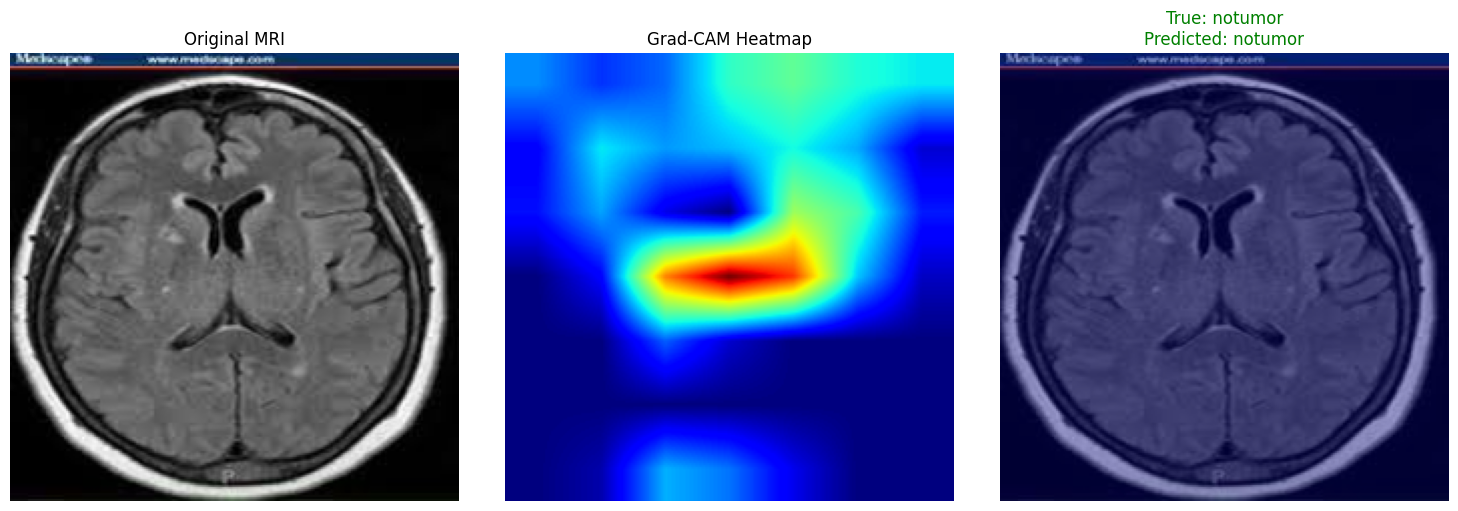

Saved: gradcam_notumor.png


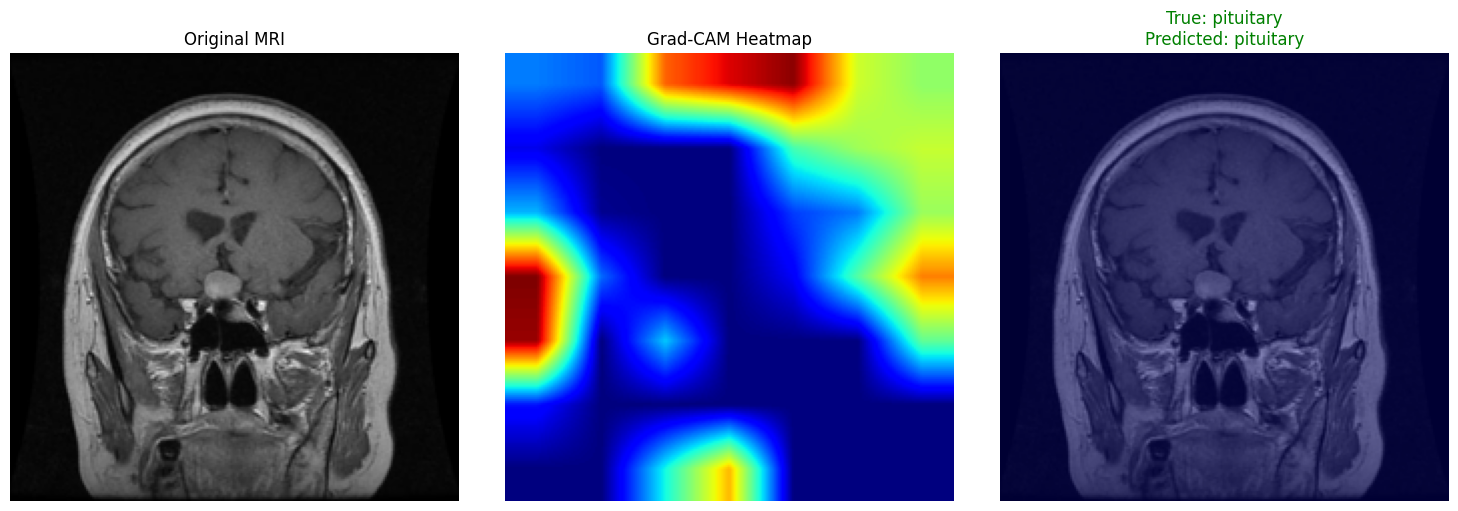

Saved: gradcam_pituitary.png


In [16]:
# Define class names and apply Grad-CAM on one sample per class
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
y_true = np.argmax(y_test, axis=1)

import os
gradcam_output_path = f'{PROJECT_PATH}/results/gradcam_samples'
os.makedirs(gradcam_output_path, exist_ok=True)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_indices = np.where(y_true == class_idx)[0]

    sample_idx = None
    for idx in class_indices:
        img = X_test[idx:idx+1]
        _, pred = make_gradcam_heatmap(img, model_transfer)
        if pred == class_idx:
            sample_idx = idx
            break

    if sample_idx is None:
        print(f"No correct prediction found for {class_name}")
        continue

    img_array = X_test[sample_idx:sample_idx+1]
    heatmap, pred_class = make_gradcam_heatmap(
        img_array, model_transfer
    )

    fig = display_gradcam(
        img_array=X_test[sample_idx],
        heatmap=heatmap,
        true_label=class_idx,
        pred_label=pred_class,
        class_names=CLASS_NAMES
    )

    save_path = f'{gradcam_output_path}/gradcam_{class_name}.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Saved: gradcam_{class_name}.png")

Finding misclassified glioma samples...
Found 3 misclassified glioma samples


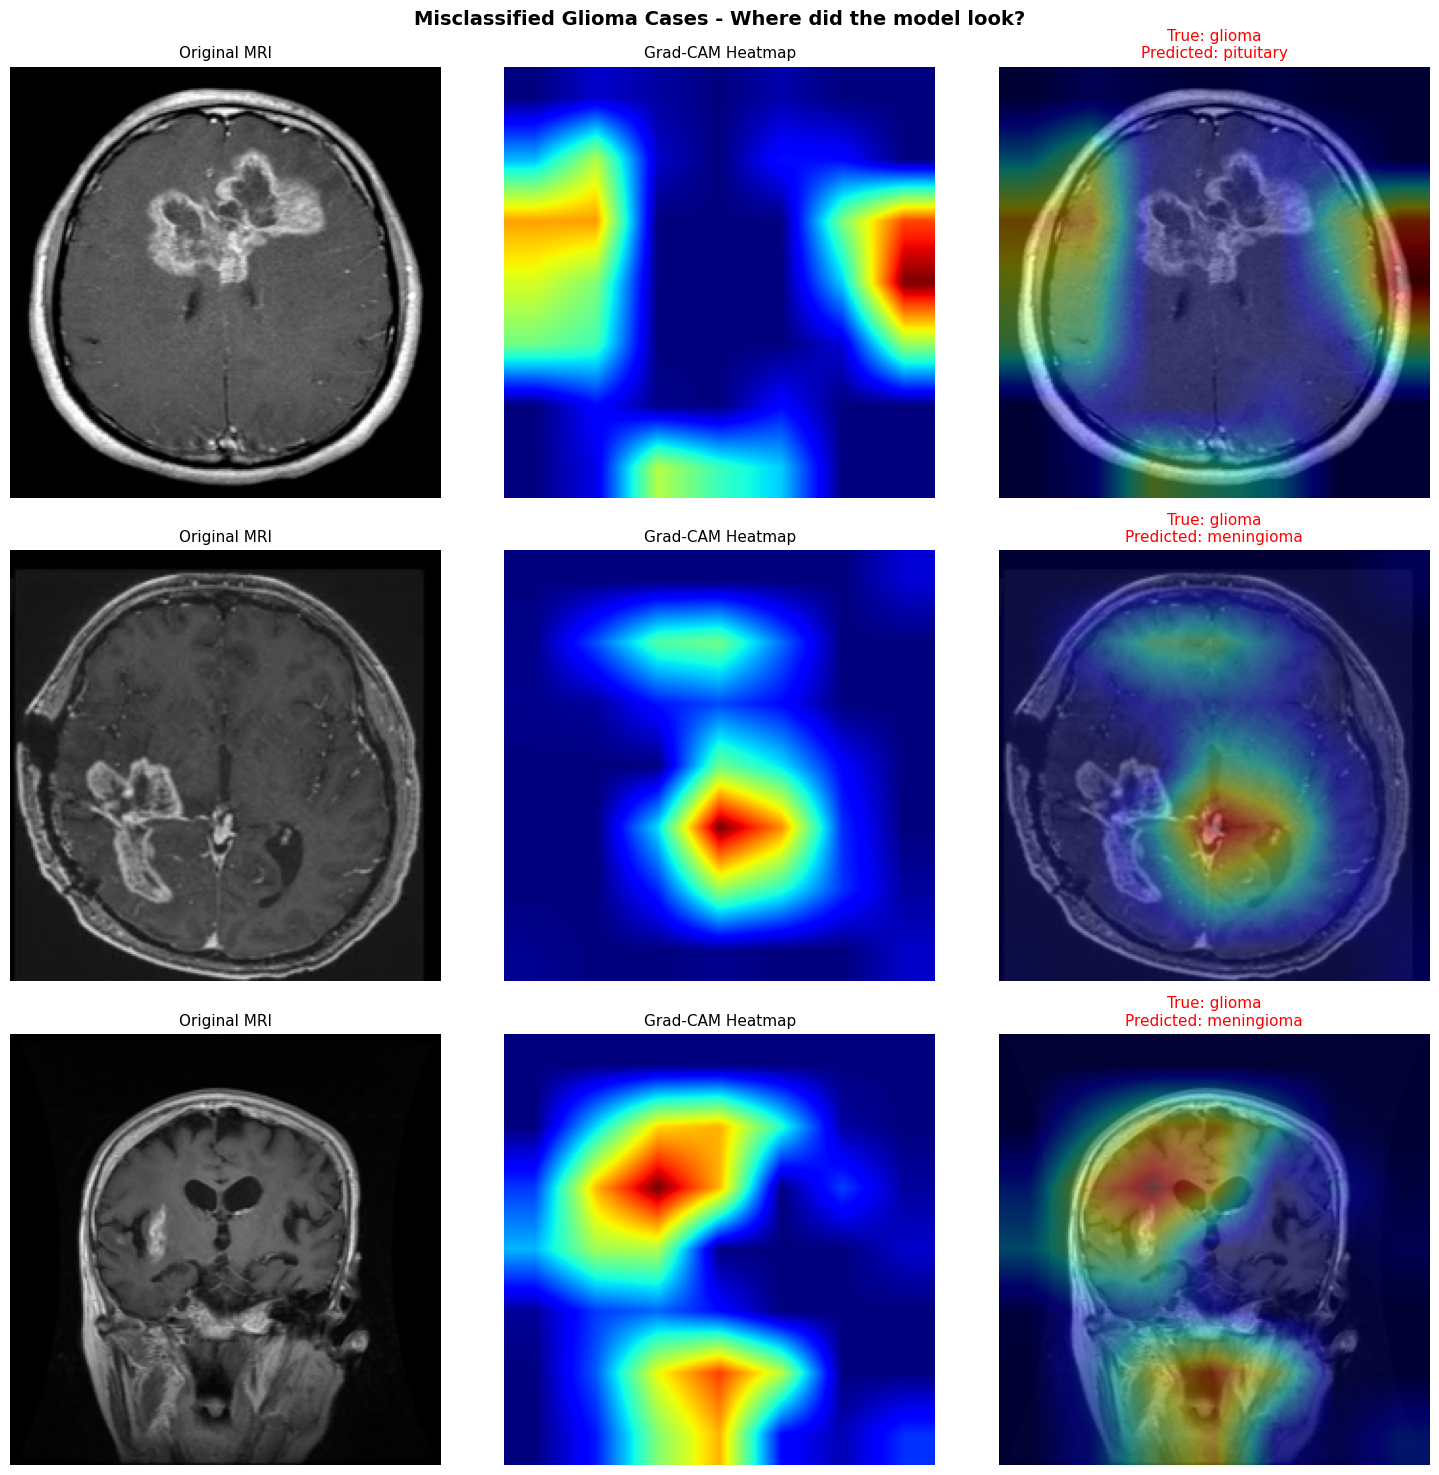

Saved: gradcam_glioma_wrong.png


In [17]:
# Visualize WRONG predictions for glioma specifically
print("Finding misclassified glioma samples...")

glioma_indices = np.where(y_true == 0)[0]  # 0 = glioma
wrong_glioma = []

for idx in glioma_indices:
    img = X_test[idx:idx+1]
    _, pred = make_gradcam_heatmap(img, model_transfer)
    if pred != 0:  # predicted wrong
        wrong_glioma.append((idx, pred))
    if len(wrong_glioma) == 3:  # get 3 wrong samples
        break

print(f"Found {len(wrong_glioma)} misclassified glioma samples")

fig, axes_grid = plt.subplots(3, 3, figsize=(15, 15))

for row, (idx, pred) in enumerate(wrong_glioma):
    img_array = X_test[idx:idx+1]
    heatmap, pred_class = make_gradcam_heatmap(img_array, model_transfer)

    import cv2
    import matplotlib.cm as cm

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    heatmap_colored = (heatmap_colored * 255).astype('uint8')
    img_display = X_test[idx].astype('uint8')
    superimposed = cv2.addWeighted(img_display, 0.6, heatmap_colored, 0.4, 0)

    axes_grid[row, 0].imshow(img_display)
    axes_grid[row, 0].set_title('Original MRI', fontsize=11)
    axes_grid[row, 0].axis('off')

    axes_grid[row, 1].imshow(heatmap_resized, cmap='jet')
    axes_grid[row, 1].set_title('Grad-CAM Heatmap', fontsize=11)
    axes_grid[row, 1].axis('off')

    axes_grid[row, 2].imshow(superimposed)
    axes_grid[row, 2].set_title(
        f'True: glioma\nPredicted: {CLASS_NAMES[pred_class]}',
        fontsize=11, color='red'
    )
    axes_grid[row, 2].axis('off')

plt.suptitle('Misclassified Glioma Cases - Where did the model look?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{gradcam_output_path}/gradcam_glioma_wrong.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gradcam_glioma_wrong.png")